# NB02 — FAISS + HDBSCAN Clustering

**Tujuan:** Mengelompokkan wajah berdasarkan embedding dari NB01 menggunakan pipeline yang dioptimasi:  
FAISS (k-NN graph) → precomputed distance matrix → HDBSCAN

**Input:** `embeddings.npy`, `metadata.pkl` (output NB01)  
**Output:** `labels.npy`, `cluster_summary.pkl`

---

**Alur pipeline:**
```
embeddings (11902 × 512, L2-normalized)
  → faiss.normalize_L2()          ← pastikan norma = 1
  → FAISS IndexFlatIP             ← bangun index (~1 detik)
  → index.search(k=15)           ← cari 15 tetangga terdekat tiap embedding
       ↓ distances (cosine similarity)
       ↓ indices
  → 1 - distances                 ← ubah ke cosine distance
  → sparse CSR matrix (N×N)      ← isi non-neighbor = 2.0 (max cosine dist)
  → dense float32 matrix         ← input HDBSCAN
  → HDBSCAN(metric='precomputed')
  → labels array (11902,)
```

> **Keunggulan vs UMAP + HDBSCAN:**  
> UMAP membutuhkan ~beberapa menit untuk 10K+ titik di 512 dimensi.  
> FAISS k-NN langsung menghasilkan graph tetangga dalam hitungan detik,  
> sehingga HDBSCAN bisa langsung berjalan tanpa tahap reduksi dimensi.

## 0. Instalasi & Import

In [1]:
# GPU runtime wajib aktif sebelum install faiss-gpu
# faiss-gpu split jadi faiss-gpu-cu11 / faiss-gpu-cu12 tergantung versi CUDA Colab
import subprocess, sys

def install_faiss():
    # Coba cu12 dulu (Colab terbaru pakai CUDA 12.x)
    for pkg in ["faiss-gpu-cu12", "faiss-gpu-cu11", "faiss-cpu"]:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f"✅ Berhasil install: {pkg}")
            return pkg
    raise RuntimeError("Gagal install faiss — coba manual: !pip install faiss-cpu")

faiss_pkg = install_faiss()
!pip install hdbscan scikit-learn matplotlib scipy tqdm -q

✅ Berhasil install: faiss-gpu-cu12


In [4]:
import os
import pickle
import time
import warnings
from pathlib import Path
from collections import Counter

import faiss
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image
from scipy.sparse import csr_matrix
from tqdm.notebook import tqdm
from importlib.metadata import version

warnings.filterwarnings('ignore')

print(f"faiss  version : {faiss.__version__}")
print(f"hdbscan version: {version('hdbscan')}")

# Verifikasi GPU untuk FAISS
try:
    ngpu = faiss.get_num_gpus()
    print(f"FAISS GPU count: {ngpu}  {'(GPU aktif)' if ngpu > 0 else '(hanya CPU)'}")
except Exception:
    print("FAISS GPU: tidak tersedia, pakai CPU")

faiss  version : 1.14.1
hdbscan version: 0.8.41
FAISS GPU count: 1  (GPU aktif)


## 1. Konfigurasi

In [5]:
# Jika pakai Google Drive — jalankan cell ini
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
# ─── SESUAIKAN PATH INI ───────────────────────────────────────────────────────
INPUT_DIR  = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb01")  # output NB01
OUTPUT_DIR = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb02")  # output NB02
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Hyperparameter FAISS ────────────────────────────────────────────────────
K_NEIGHBORS = 15   # jumlah tetangga terdekat per embedding
                   # lebih besar → graph lebih padat → HDBSCAN lebih lambat tapi lebih akurat

# ─── Hyperparameter HDBSCAN ──────────────────────────────────────────────────
MIN_CLUSTER_SIZE = 5    # minimal anggota per cluster
                        # makin kecil → lebih banyak cluster kecil
MIN_SAMPLES      = 3    # ketegasan penentuan core point
                        # makin besar → lebih banyak noise (-1)
CLUSTER_METHOD   = 'eom'  # 'eom' (excess of mass) atau 'leaf'
                          # 'eom' → cluster lebih besar & hierarkis
                          # 'leaf' → cluster lebih banyak & granular

print(f"Input dir  : {INPUT_DIR}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Input ada  : {INPUT_DIR.exists()}")
print()
print(f"K_NEIGHBORS      : {K_NEIGHBORS}")
print(f"MIN_CLUSTER_SIZE : {MIN_CLUSTER_SIZE}")
print(f"MIN_SAMPLES      : {MIN_SAMPLES}")
print(f"CLUSTER_METHOD   : {CLUSTER_METHOD}")

Input dir  : /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb01
Output dir : /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb02
Input ada  : True

K_NEIGHBORS      : 15
MIN_CLUSTER_SIZE : 5
MIN_SAMPLES      : 3
CLUSTER_METHOD   : eom


## 2. Load Output NB01

In [7]:
emb_path  = INPUT_DIR / "embeddings.npy"
meta_path = INPUT_DIR / "metadata.pkl"

embeddings = np.load(emb_path).astype(np.float32)   # FAISS butuh float32

with open(meta_path, "rb") as f:
    metadata = pickle.load(f)

N, D = embeddings.shape

print(f"Embeddings shape : {embeddings.shape}")
print(f"Dtype            : {embeddings.dtype}")
print(f"Metadata records : {len(metadata)}")

# Verifikasi L2-norm (seharusnya sudah ≈ 1.0 dari NB01)
norms = np.linalg.norm(embeddings, axis=1)
print(f"\nL2-norm check — min: {norms.min():.6f}, max: {norms.max():.6f}")
if norms.max() - norms.min() < 0.01:
    print("✅ Embedding sudah L2-normalized")
else:
    print("⚠️  Embedding belum dinormalisasi — akan dinormalisasi otomatis di langkah berikut")

# Estimasi memori matrix precomputed
mem_mb = (N * N * 4) / (1024**2)
print(f"\nEstimasi memori dense distance matrix ({N}×{N} float32): {mem_mb:.0f} MB")

Embeddings shape : (11902, 512)
Dtype            : float32
Metadata records : 11902

L2-norm check — min: 1.000000, max: 1.000000
✅ Embedding sudah L2-normalized

Estimasi memori dense distance matrix (11902×11902 float32): 540 MB


## 3. Build FAISS Index

`IndexFlatIP` = Flat Inner Product index.  
Karena vektor sudah **L2-normalized**, inner product = cosine similarity.  
Index ini tidak mengkompresi data (exact search), cocok untuk dataset < 1 juta embedding.

In [8]:
# Buat salinan agar embeddings asli tidak berubah
emb_faiss = embeddings.copy()

t0 = time.time()

# Pastikan L2-normalized (faiss.normalize_L2 in-place)
faiss.normalize_L2(emb_faiss)

# Bangun index
index = faiss.IndexFlatIP(D)   # Inner Product (= cosine sim untuk vektor normalized)
index.add(emb_faiss)

t_build = time.time() - t0

print(f"FAISS IndexFlatIP")
print(f"  Dimensi        : {D}")
print(f"  Total vektor   : {index.ntotal:,}")
print(f"  Waktu build    : {t_build:.3f} detik")

FAISS IndexFlatIP
  Dimensi        : 512
  Total vektor   : 11,902
  Waktu build    : 0.019 detik


## 4. Query K-NN dengan FAISS

Untuk setiap embedding, cari **K tetangga terdekat** berdasarkan cosine similarity.  
FAISS mengembalikan:
- `distances` (N × K): cosine similarity antara setiap embedding dengan K tetangganya
- `indices` (N × K): indeks K tetangga terdekat di dalam array embedding

> **Catatan:** Tetangga pertama (kolom 0) adalah embedding itu sendiri (similarity = 1.0), akan diabaikan saat membangun graph.

In [9]:
t0 = time.time()

# +1 karena tetangga pertama adalah dirinya sendiri
distances_sim, indices_knn = index.search(emb_faiss, K_NEIGHBORS + 1)

t_query = time.time() - t0

# Hapus tetangga pertama (diri sendiri: similarity = 1.0, distance = 0)
distances_sim = distances_sim[:, 1:]   # shape: (N, K)
indices_knn   = indices_knn[:, 1:]     # shape: (N, K)

print(f"K-NN Query selesai")
print(f"  Waktu query       : {t_query:.3f} detik")
print(f"  Shape distances   : {distances_sim.shape}  (N × K cosine similarity)")
print(f"  Shape indices     : {indices_knn.shape}")
print()
print(f"Statistik cosine similarity tetangga:")
print(f"  Min  : {distances_sim.min():.4f}")
print(f"  Max  : {distances_sim.max():.4f}")
print(f"  Mean : {distances_sim.mean():.4f}")
print(f"  Median: {np.median(distances_sim):.4f}")

# Distribusi similarity tetangga terdekat (kolom 0 = tetangga paling dekat)
print(f"\nMean similarity per rank tetangga:")
for rank in [0, 4, 9, 14]:
    if rank < K_NEIGHBORS:
        print(f"  Tetangga ke-{rank+1:2d}: {distances_sim[:, rank].mean():.4f}")

K-NN Query selesai
  Waktu query       : 2.211 detik
  Shape distances   : (11902, 15)  (N × K cosine similarity)
  Shape indices     : (11902, 15)

Statistik cosine similarity tetangga:
  Min  : 0.2183
  Max  : 0.9899
  Mean : 0.8201
  Median: 0.8501

Mean similarity per rank tetangga:
  Tetangga ke- 1: 0.8888
  Tetangga ke- 5: 0.8336
  Tetangga ke-10: 0.8029
  Tetangga ke-15: 0.7802


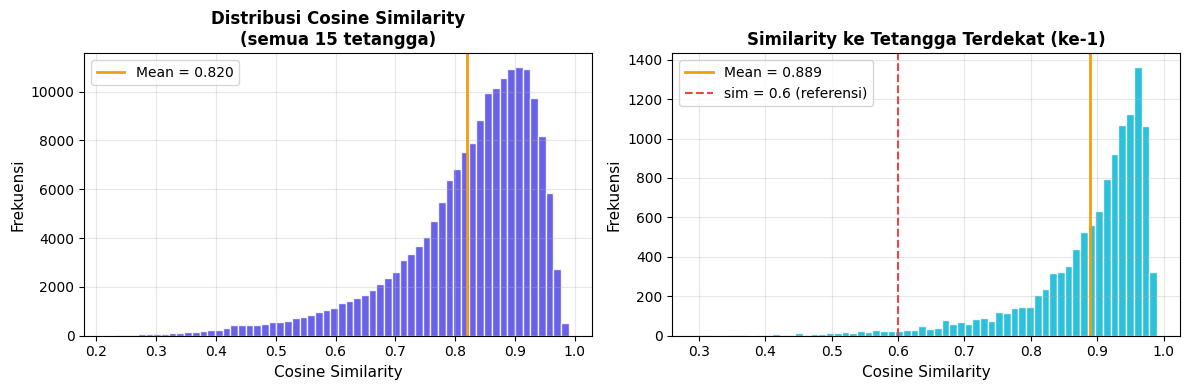

Persentase embedding dengan tetangga terdekat > 0.8: 86.7%
Persentase embedding dengan tetangga terdekat > 0.6: 97.8%


In [10]:
# Visualisasi distribusi cosine similarity tetangga
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram semua similarity
axes[0].hist(distances_sim.flatten(), bins=60, color='#4F46E5', edgecolor='white', alpha=0.85)
axes[0].axvline(distances_sim.mean(), color='#F59E0B', linewidth=2,
                label=f"Mean = {distances_sim.mean():.3f}")
axes[0].set_xlabel("Cosine Similarity", fontsize=11)
axes[0].set_ylabel("Frekuensi", fontsize=11)
axes[0].set_title(f"Distribusi Cosine Similarity\n(semua {K_NEIGHBORS} tetangga)", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Similarity tetangga ke-1 (paling dekat) per embedding
nearest_sim = distances_sim[:, 0]
axes[1].hist(nearest_sim, bins=60, color='#06B6D4', edgecolor='white', alpha=0.85)
axes[1].axvline(nearest_sim.mean(), color='#F59E0B', linewidth=2,
                label=f"Mean = {nearest_sim.mean():.3f}")
axes[1].axvline(0.6, color='#EF4444', linewidth=1.5, linestyle='--', label='sim = 0.6 (referensi)')
axes[1].set_xlabel("Cosine Similarity", fontsize=11)
axes[1].set_ylabel("Frekuensi", fontsize=11)
axes[1].set_title("Similarity ke Tetangga Terdekat (ke-1)", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_similarity_knn.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Persentase embedding dengan tetangga terdekat > 0.8: "
      f"{(nearest_sim > 0.8).mean()*100:.1f}%")
print(f"Persentase embedding dengan tetangga terdekat > 0.6: "
      f"{(nearest_sim > 0.6).mean()*100:.1f}%")

## 5. Bangun Precomputed Distance Matrix

HDBSCAN dengan `metric='precomputed'` menerima matrix **jarak** (bukan similarity).  
Konversi: **cosine distance = 1 − cosine similarity**

Karena hanya K tetangga yang diketahui, pasangan non-tetangga diisi dengan **2.0**  
(nilai maksimum cosine distance untuk vektor normalized) — artinya "sangat jauh".

```
cosine similarity ∈ [−1, 1]  →  cosine distance ∈ [0, 2]
untuk normalized vectors (norma=1): similarity ∈ [0, 1]
```

In [11]:
t0 = time.time()

# Konversi cosine similarity → cosine distance
cos_dist = (1.0 - distances_sim).astype(np.float32)   # shape: (N, K)
cos_dist = np.clip(cos_dist, 0.0, 2.0)                 # jaga agar tidak negatif karena floating point

# Bangun sparse CSR matrix: hanya isi entri k-NN
rows = np.repeat(np.arange(N), K_NEIGHBORS)   # [0,0,...,0, 1,1,...,1, ...]
cols = indices_knn.flatten()                   # indeks tetangga
data = cos_dist.flatten()                      # jarak ke tetangga

sparse_dist = csr_matrix((data, (rows, cols)), shape=(N, N))

# Simetrisasi: D[i,j] = D[j,i] = min(D[i,j], D[j,i]) jika keduanya ada,
# atau nilai yang ada jika hanya satu arah
sparse_dist = (sparse_dist + sparse_dist.T)
# Bagi 2 hanya untuk entri yang terisi dari kedua arah
# (entri yang hanya dari satu arah tetap bernilai aslinya)
# Cara sederhana: ambil max (lebih konservatif untuk HDBSCAN)
sparse_dist_T = sparse_dist.T
# Sudah simetris setelah operasi + di atas

# Set diagonal = 0 (jarak ke diri sendiri)
sparse_dist.setdiag(0)
sparse_dist.eliminate_zeros()

t_sparse = time.time() - t0
print(f"Sparse distance matrix selesai ({t_sparse:.2f} detik)")
print(f"  Shape      : {sparse_dist.shape}")
print(f"  Non-zero   : {sparse_dist.nnz:,}  ({sparse_dist.nnz / (N*N) * 100:.2f}% density)")
print(f"  Nilai min  : {sparse_dist.data.min():.4f}")
print(f"  Nilai max  : {sparse_dist.data.max():.4f}")

Sparse distance matrix selesai (0.03 detik)
  Shape      : (11902, 11902)
  Non-zero   : 247,674  (0.17% density)
  Nilai min  : 0.0202
  Nilai max  : 1.4362


In [12]:
# Konversi ke dense matrix — isi non-neighbor = 2.0 (max cosine distance)
# HDBSCAN metric='precomputed' membutuhkan matrix penuh (N × N)

t0 = time.time()

print(f"Mengkonversi ke dense matrix ({N}×{N}, float32)...")
print(f"Estimasi memori: {N*N*4/1024**2:.0f} MB")

# Mulai dari matrix isi 2.0 (semua pasangan dianggap maksimum jauh)
dense_dist = np.full((N, N), 2.0, dtype=np.float32)

# Isi entri yang diketahui dari sparse matrix
cx = sparse_dist.tocoo()
dense_dist[cx.row, cx.col] = cx.data

# Set diagonal = 0
np.fill_diagonal(dense_dist, 0.0)

t_dense = time.time() - t0

actual_mem = dense_dist.nbytes / 1024**2
print(f"\nDense matrix selesai ({t_dense:.2f} detik)")
print(f"  Shape      : {dense_dist.shape}")
print(f"  Dtype      : {dense_dist.dtype}")
print(f"  Memori     : {actual_mem:.0f} MB")
print(f"  Min        : {dense_dist.min():.4f}")
print(f"  Max        : {dense_dist.max():.4f}")

# Verifikasi simetri (sample)
sample_i, sample_j = 0, 5
print(f"\nVerifikasi simetri — D[0,5] = {dense_dist[0,5]:.4f}, D[5,0] = {dense_dist[5,0]:.4f}")

# Bebas sparse matrix — hemat RAM
del sparse_dist, cx

Mengkonversi ke dense matrix (11902×11902, float32)...
Estimasi memori: 540 MB

Dense matrix selesai (0.14 detik)
  Shape      : (11902, 11902)
  Dtype      : float32
  Memori     : 540 MB
  Min        : 0.0000
  Max        : 2.0000

Verifikasi simetri — D[0,5] = 2.0000, D[5,0] = 2.0000


## 6. HDBSCAN Clustering

HDBSCAN (**Hierarchical Density-Based Spatial Clustering of Applications with Noise**)  
menerima precomputed distance matrix dan menghasilkan label cluster untuk tiap embedding.

| Label | Arti |
|-------|------|
| `0, 1, 2, ...` | Cluster valid (label numerik) |
| `-1` | **Noise** — embedding yang tidak masuk cluster manapun |

> **`min_cluster_size`** = jumlah minimum anggota agar sebuah grup dianggap cluster  
> **`min_samples`** = jumlah minimum tetangga agar titik dianggap *core point*

In [13]:
t0 = time.time()

clusterer = hdbscan.HDBSCAN(
    min_cluster_size        = MIN_CLUSTER_SIZE,
    min_samples             = MIN_SAMPLES,
    metric                  = 'precomputed',
    cluster_selection_method= CLUSTER_METHOD,
    approx_min_span_tree    = True,    # lebih cepat, hampir sama akuratnya
    core_dist_n_jobs        = -1,      # pakai semua CPU core
)

labels = clusterer.fit_predict(dense_dist)

t_hdbscan = time.time() - t0

# ── Statistik dasar ────────────────────────────────────────────────────────────
n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
n_noise     = int((labels == -1).sum())
n_clustered = int((labels >= 0).sum())
coverage    = n_clustered / N * 100

print(f"HDBSCAN selesai ({t_hdbscan:.2f} detik)")
print()
print(f"  Jumlah cluster     : {n_clusters}")
print(f"  Total embedding    : {N:,}")
print(f"  Masuk cluster      : {n_clustered:,}  ({coverage:.1f}%)")
print(f"  Noise (-1)         : {n_noise:,}  ({n_noise/N*100:.1f}%)")

ValueError: Buffer dtype mismatch, expected 'double_t' but got 'float'

## 7. Analisis Hasil Clustering

In [ ]:
# ── Distribusi ukuran cluster ──────────────────────────────────────────────────
cluster_sizes = Counter(labels[labels >= 0])
sizes = sorted(cluster_sizes.values(), reverse=True)

print(f"{'='*52}")
print(f"  ANALISIS HASIL CLUSTERING")
print(f"{'='*52}")
print(f"  Jumlah cluster     : {n_clusters}")
print(f"  Embedding clustered: {n_clustered:,}  ({coverage:.1f}%)")
print(f"  Noise              : {n_noise:,}  ({n_noise/N*100:.1f}%)")
print()
print(f"  Ukuran cluster — Min : {min(sizes)}")
print(f"                   Max : {max(sizes)}")
print(f"                   Mean: {np.mean(sizes):.1f}")
print(f"                   Median: {np.median(sizes):.0f}")
print()

# Breakdown ukuran
thresholds = [1, 5, 10, 20, 50, 100]
print(f"  Distribusi ukuran cluster:")
prev = 0
for thr in thresholds:
    count = sum(1 for s in sizes if prev < s <= thr)
    print(f"    {prev+1:3d} – {thr:3d} wajah : {count:4d} cluster")
    prev = thr
count_large = sum(1 for s in sizes if s > 100)
print(f"    > 100 wajah   : {count_large:4d} cluster")

print()
print(f"  TOP 10 CLUSTER TERBESAR:")
print(f"  {'Cluster':>8}  {'Jumlah Wajah':>14}")
print(f"  {'-'*28}")
for cluster_id, size in cluster_sizes.most_common(10):
    print(f"  Cluster {cluster_id:>4d}  {size:>14,} wajah")

In [ ]:
# ── Rekap waktu eksekusi tiap tahap ────────────────────────────────────────────
print(f"{'='*50}")
print(f"  REKAP WAKTU EKSEKUSI PIPELINE")
print(f"{'='*50}")
print(f"  FAISS index build   : {t_build:.3f} detik")
print(f"  FAISS k-NN query    : {t_query:.3f} detik")
print(f"  Sparse matrix build : {t_sparse:.3f} detik")
print(f"  Dense matrix build  : {t_dense:.3f} detik")
print(f"  HDBSCAN fit_predict : {t_hdbscan:.3f} detik")
t_total = t_build + t_query + t_sparse + t_dense + t_hdbscan
print(f"  {'─'*38}")
print(f"  TOTAL               : {t_total:.3f} detik ({t_total/60:.1f} menit)")
print(f"{'='*50}")

## 8. Visualisasi

In [ ]:
# ── 8a. Distribusi ukuran cluster ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart top-30 cluster
top_n = 30
top_clusters = cluster_sizes.most_common(top_n)
top_ids   = [str(c[0]) for c in top_clusters]
top_sizes = [c[1] for c in top_clusters]

bars = axes[0].bar(range(top_n), top_sizes, color='#4F46E5', edgecolor='white')
axes[0].set_xticks(range(0, top_n, 5))
axes[0].set_xticklabels([top_ids[i] for i in range(0, top_n, 5)], rotation=45, ha='right')
axes[0].set_xlabel("Cluster ID", fontsize=11)
axes[0].set_ylabel("Jumlah Wajah", fontsize=11)
axes[0].set_title(f"Top {top_n} Cluster Terbesar", fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogram semua ukuran cluster
axes[1].hist(sizes, bins=30, color='#06B6D4', edgecolor='white')
axes[1].axvline(np.mean(sizes), color='#F59E0B', linewidth=2,
                label=f"Mean = {np.mean(sizes):.0f}")
axes[1].set_xlabel("Ukuran Cluster (jumlah wajah)", fontsize=11)
axes[1].set_ylabel("Jumlah Cluster", fontsize=11)
axes[1].set_title("Distribusi Ukuran Semua Cluster", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_cluster.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 8b. Overview: clustered vs noise ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie: clustered vs noise
pie_vals   = [n_clustered, n_noise]
pie_labels = [f"Clustered\n({n_clustered:,})", f"Noise\n({n_noise:,})"]
pie_colors = ['#4F46E5', '#94A3B8']
axes[0].pie(pie_vals, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[0].set_title("Komposisi Hasil Clustering", fontsize=12, fontweight='bold')

# Cumulative coverage: berapa % embedding tercakup top-N cluster
cumsum = np.cumsum(sizes)
cumsum_pct = cumsum / N * 100
axes[1].plot(range(1, len(sizes)+1), cumsum_pct, color='#4F46E5', linewidth=2)
axes[1].axhline(80, color='#F59E0B', linewidth=1.5, linestyle='--', label='80% coverage')
axes[1].axhline(90, color='#EF4444', linewidth=1.5, linestyle='--', label='90% coverage')
top_80 = int(np.searchsorted(cumsum_pct, 80)) + 1
top_90 = int(np.searchsorted(cumsum_pct, 90)) + 1
axes[1].set_xlabel("Jumlah Cluster (urut terbesar)", fontsize=11)
axes[1].set_ylabel("Kumulatif % Embedding", fontsize=11)
axes[1].set_title("Cumulative Coverage Top-N Cluster", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "coverage_cluster.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Top {top_80} cluster mencakup 80% embedding")
print(f"Top {top_90} cluster mencakup 90% embedding")

In [ ]:
# ── 8c. Sample face crops dari top cluster ────────────────────────────────────
def crop_face(photo_path, bbox, padding=0.25, size=112):
    """Crop wajah dari foto berdasarkan bounding box + padding."""
    try:
        img = Image.open(photo_path).convert("RGB")
        W, H = img.size
        x1, y1, x2, y2 = bbox
        bw, bh = x2 - x1, y2 - y1
        x1 = max(0, x1 - bw * padding)
        y1 = max(0, y1 - bh * padding)
        x2 = min(W, x2 + bw * padding)
        y2 = min(H, y2 + bh * padding)
        return img.crop((x1, y1, x2, y2)).resize((size, size))
    except Exception:
        return Image.new('RGB', (size, size), color=(200, 200, 200))  # placeholder abu-abu

n_show_clusters = 10     # berapa cluster yang ditampilkan
n_show_per_row  = 8      # berapa wajah per cluster

top_cluster_ids = [c[0] for c in cluster_sizes.most_common(n_show_clusters)]

fig, axes = plt.subplots(n_show_clusters, n_show_per_row,
                         figsize=(n_show_per_row * 1.5, n_show_clusters * 1.6))
fig.suptitle(f"Sample Wajah dari Top {n_show_clusters} Cluster Terbesar",
             fontsize=13, fontweight='bold', y=1.01)

for row, cluster_id in enumerate(top_cluster_ids):
    # Indeks embedding di cluster ini
    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_size    = len(cluster_indices)

    # Pilih sample acak (seed per cluster untuk reprodusibilitas)
    rng = np.random.default_rng(seed=42 + cluster_id)
    sample_n = min(n_show_per_row, cluster_size)
    sample_indices = rng.choice(cluster_indices, size=sample_n, replace=False)

    for col in range(n_show_per_row):
        ax = axes[row, col]
        if col < sample_n:
            idx = sample_indices[col]
            m   = metadata[idx]
            crop = crop_face(m['photo_path'], m['bbox'])
            ax.imshow(crop)
            if col == 0:
                ax.set_ylabel(f"C{cluster_id}\n({cluster_size})",
                              fontsize=8, rotation=0, labelpad=35, va='center')
        else:
            ax.set_facecolor('#F1F5F9')
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_cluster_faces.png", dpi=150, bbox_inches='tight')
plt.show()

print("Preview tersimpan: sample_cluster_faces.png")

## 9. Simpan Output

In [ ]:
# ── 9a. Simpan labels ──────────────────────────────────────────────────────────
labels_path = OUTPUT_DIR / "labels.npy"
np.save(labels_path, labels)

# ── 9b. Bangun cluster_summary: mapping cluster → daftar metadata ──────────────
cluster_summary = {
    "n_clusters"        : n_clusters,
    "n_noise"           : n_noise,
    "n_clustered"       : n_clustered,
    "coverage_pct"      : coverage,
    "cluster_sizes"     : dict(cluster_sizes),
    "timing": {
        "faiss_build_sec" : t_build,
        "faiss_query_sec" : t_query,
        "sparse_build_sec": t_sparse,
        "dense_build_sec" : t_dense,
        "hdbscan_sec"     : t_hdbscan,
        "total_sec"       : t_total,
    },
    "params": {
        "k_neighbors"       : K_NEIGHBORS,
        "min_cluster_size"  : MIN_CLUSTER_SIZE,
        "min_samples"       : MIN_SAMPLES,
        "cluster_method"    : CLUSTER_METHOD,
    },
}

# Tambahkan label ke metadata
metadata_with_labels = []
for i, m in enumerate(metadata):
    entry = dict(m)
    entry['cluster_id'] = int(labels[i])
    metadata_with_labels.append(entry)

summary_path = OUTPUT_DIR / "cluster_summary.pkl"
meta_labeled_path = OUTPUT_DIR / "metadata_labeled.pkl"

with open(summary_path, "wb") as f:
    pickle.dump(cluster_summary, f)

with open(meta_labeled_path, "wb") as f:
    pickle.dump(metadata_with_labels, f)

print("Output tersimpan:")
print(f"  {labels_path}        ({labels_path.stat().st_size / 1024:.1f} KB)")
print(f"  {summary_path}  ({summary_path.stat().st_size / 1024:.1f} KB)")
print(f"  {meta_labeled_path}  ({meta_labeled_path.stat().st_size / 1024:.1f} KB)")

## 10. Ringkasan

In [ ]:
print("=" * 56)
print("  RINGKASAN NB02 — FAISS + HDBSCAN CLUSTERING")
print("=" * 56)
print(f"  Input embeddings     : {N:,} wajah × {D} dimensi")
print()
print(f"  [FAISS]")
print(f"    Index              : IndexFlatIP (cosine similarity)")
print(f"    K tetangga         : {K_NEIGHBORS}")
print(f"    Waktu build+query  : {t_build+t_query:.3f} detik")
print()
print(f"  [HDBSCAN]")
print(f"    metric             : precomputed (cosine distance)")
print(f"    min_cluster_size   : {MIN_CLUSTER_SIZE}")
print(f"    min_samples        : {MIN_SAMPLES}")
print(f"    cluster_method     : {CLUSTER_METHOD}")
print(f"    Waktu clustering   : {t_hdbscan:.3f} detik")
print()
print(f"  [Hasil]")
print(f"    Jumlah cluster     : {n_clusters}")
print(f"    Wajah ter-cluster  : {n_clustered:,}  ({coverage:.1f}%)")
print(f"    Noise              : {n_noise:,}  ({n_noise/N*100:.1f}%)")
print(f"    Cluster terbesar   : {max(sizes)} wajah")
print(f"    Cluster terkecil   : {min(sizes)} wajah")
print()
print(f"  [Waktu Total Pipeline]")
print(f"    {t_total:.1f} detik = {t_total/60:.2f} menit")
print()
print(f"  Output:")
print(f"    labels.npy            → shape ({N},)")
print(f"    cluster_summary.pkl   → statistik & timing")
print(f"    metadata_labeled.pkl  → {N:,} records + cluster_id")
print("=" * 56)
print()
print("➜  Lanjut ke NB03_Evaluasi_Clustering.ipynb")